In [13]:
import pandas as pd

df = pd.read_csv("../data/raw/annotations.csv")
print("Shape:", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)
print("\nFirst 3 Rows:")
print(df.head(3))

Shape: (1186, 5)

Column Data Types:
seriesuid          str
coordX         float64
coordY         float64
coordZ         float64
diameter_mm    float64
dtype: object

First 3 Rows:
                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -128.699421 -175.319272   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.783651 -211.925149   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...   69.639017 -140.944586   

       coordZ  diameter_mm  
0 -298.387506     5.651471  
1 -227.121250     4.224708  
2  876.374496     5.786348  


In [14]:
import pandas as pd

df = pd.read_csv("../data/raw/annotations.csv")
print("Total finding records:", len(df))
print("Unique studies in this CSV:", df["seriesuid"].nunique())

Total finding records: 1186
Unique studies in this CSV: 601


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned findings
df = pd.read_csv("../data/processed/clean_findings.csv")
print(f"Loaded {len(df)} records across {df['seriesuid'].nunique()} unique scans.")
df.head(3)

Loaded 1186 records across 601 unique scans.


,finding_id,seriesuid,coordX,coordY,coordZ,diameter_mm,volume_mm3
0,F-0000,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.70,-175.32,-298.39,5.65,94.51
1,F-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.78,-211.93,-227.12,4.22,39.48
2,F-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.64,-140.94,876.37,5.79,101.44


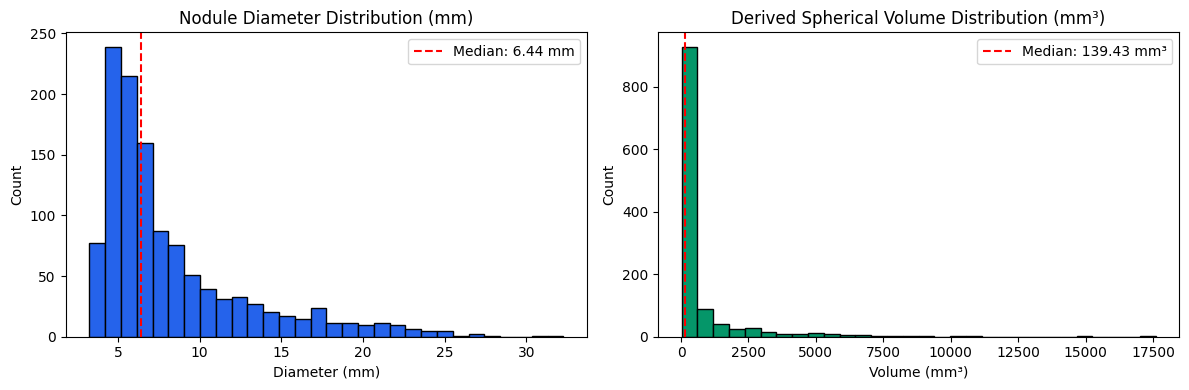

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear Diameter
axes[0].hist(df["diameter_mm"], bins=30, color="#2563eb", edgecolor="black")
axes[0].set_title("Nodule Diameter Distribution (mm)")
axes[0].set_xlabel("Diameter (mm)")
axes[0].set_ylabel("Count")
axes[0].axvline(df["diameter_mm"].median(), color="red", linestyle="--", 
                label=f"Median: {df['diameter_mm'].median():.2f} mm")
axes[0].legend()

# Cubic Volume
axes[1].hist(df["volume_mm3"], bins=30, color="#059669", edgecolor="black")
axes[1].set_title("Derived Spherical Volume Distribution (mm³)")
axes[1].set_xlabel("Volume (mm³)")
axes[1].set_ylabel("Count")
axes[1].axvline(df["volume_mm3"].median(), color="red", linestyle="--", 
                label=f"Median: {df['volume_mm3'].median():.2f} mm³")
axes[1].legend()

plt.tight_layout()
plt.show()

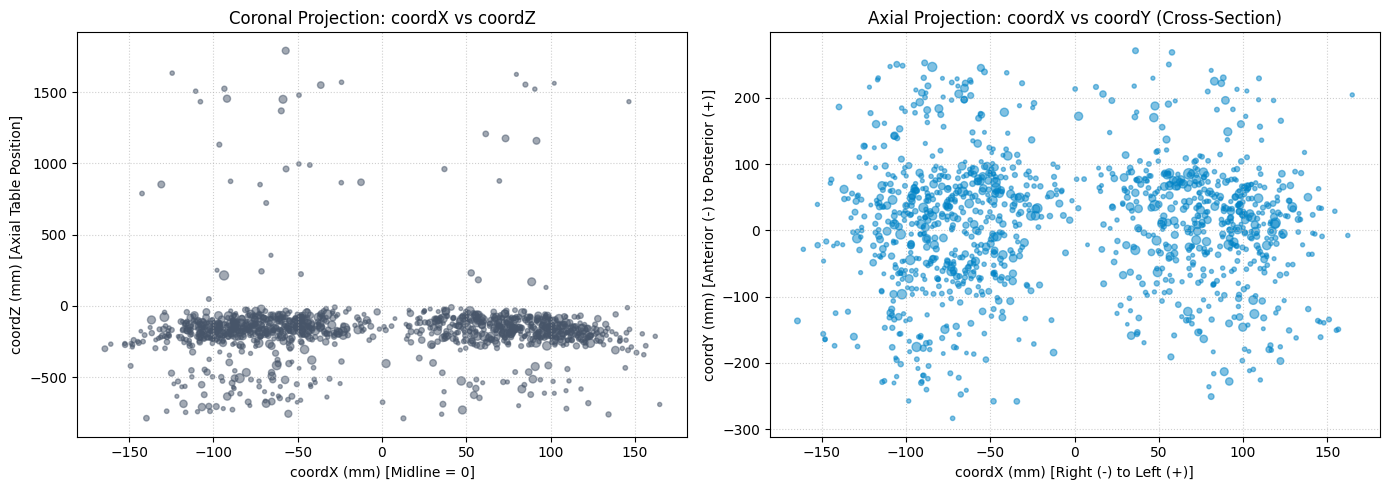

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coronal Plane: X (Lateral) vs Z (Vertical / Couch)
axes[0].scatter(df["coordX"], df["coordZ"], c="#475569", alpha=0.5, s=df["diameter_mm"] * 1.8)
axes[0].set_title("Coronal Projection: coordX vs coordZ")
axes[0].set_xlabel("coordX (mm) [Midline = 0]")
axes[0].set_ylabel("coordZ (mm) [Axial Table Position]")
axes[0].grid(True, linestyle=":", alpha=0.6)

# Axial Plane: X (Lateral) vs Y (Anterior-Posterior)
axes[1].scatter(df["coordX"], df["coordY"], c="#0284c7", alpha=0.5, s=df["diameter_mm"] * 1.8)
axes[1].set_title("Axial Projection: coordX vs coordY (Cross-Section)")
axes[1].set_xlabel("coordX (mm) [Right (-) to Left (+)]")
axes[1].set_ylabel("coordY (mm) [Anterior (-) to Posterior (+)]")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [19]:
feature_cols = ["coordX", "coordY", "coordZ", "diameter_mm", "volume_mm3"]
corr = df[feature_cols].corr().round(3)
corr


,coordX,coordY,coordZ,diameter_mm,volume_mm3
coordX,1.000,0.008,0.008,0.013,0.023
coordY,0.008,1.000,-0.278,0.079,0.057
coordZ,0.008,-0.278,1.000,0.014,0.006
diameter_mm,0.013,0.079,0.014,1.000,0.893
volume_mm3,0.023,0.057,0.006,0.893,1.000


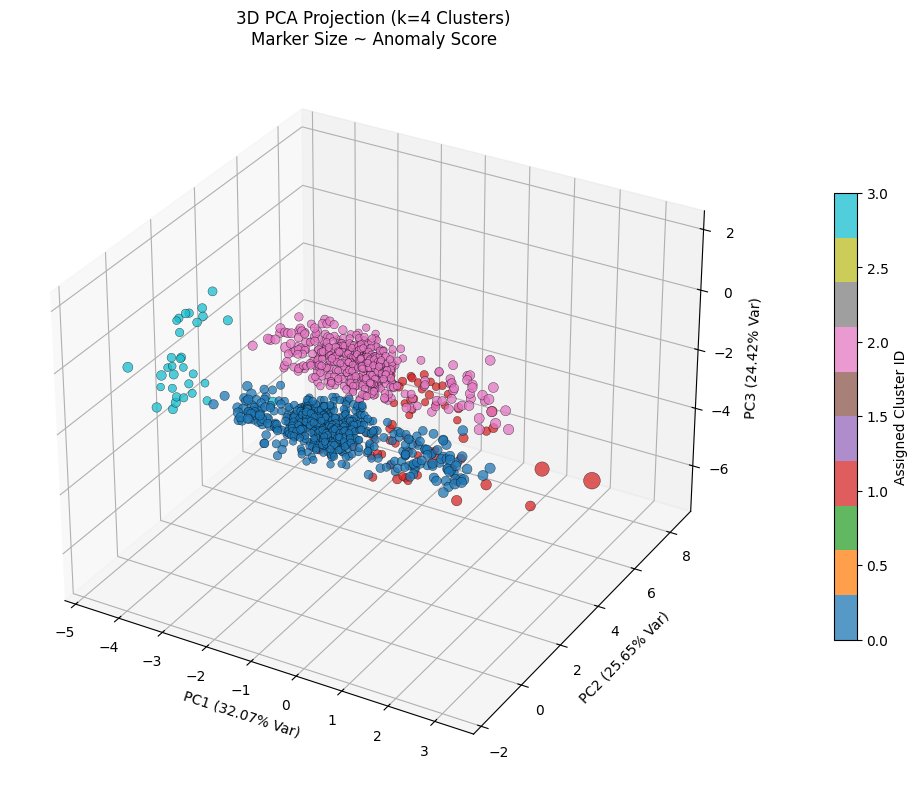

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# Load enriched findings from Day 4 pipeline
enriched_df = pd.read_csv("../data/processed/enriched_findings.csv")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Scatter: PCA coordinates colored by cluster_id, size scaled by anomaly_score
scatter = ax.scatter(
    enriched_df["pca_x"],
    enriched_df["pca_y"],
    enriched_df["pca_z"],
    c=enriched_df["cluster_id"],
    cmap="tab10",
    s=25 + (enriched_df["anomaly_score"] ** 1.5) * 120,
    alpha=0.75,
    edgecolors="black",
    linewidth=0.3,
)

ax.set_title(
    "3D PCA Projection (k=4 Clusters)\nMarker Size ~ Anomaly Score", fontsize=12
)
ax.set_xlabel("PC1 (32.07% Var)")
ax.set_ylabel("PC2 (25.65% Var)")
ax.set_zlabel("PC3 (24.42% Var)")

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("Assigned Cluster ID")

plt.tight_layout()
plt.show()

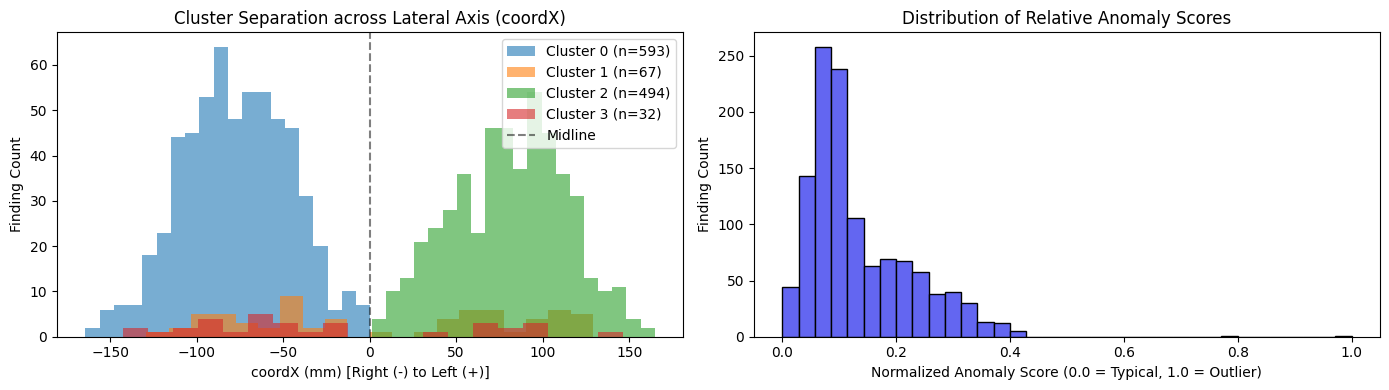

CLUSTER PROFILE SUMMARY (Means):
            coordX  coordY   coordZ  diameter_mm  volume_mm3  anomaly_score
cluster_id                                                                 
0           -77.07    7.65  -209.57         7.48      383.74           0.13
1             8.79   17.81  -170.15        22.00     5859.90           0.22
2            80.70   10.74  -190.26         7.46      381.91           0.12
3           -23.79  -32.54  1241.12         8.03      456.87           0.24


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Physical separation: Lateral coordinate (coordX) by cluster
for c_id in sorted(enriched_df["cluster_id"].unique()):
  subset = enriched_df[enriched_df["cluster_id"] == c_id]
  axes[0].hist(
      subset["coordX"],
      bins=20,
      alpha=0.6,
      label=f"Cluster {c_id} (n={len(subset)})",
  )

axes[0].set_title("Cluster Separation across Lateral Axis (coordX)")
axes[0].set_xlabel("coordX (mm) [Right (-) to Left (+)]")
axes[0].set_ylabel("Finding Count")
axes[0].axvline(0, color="black", linestyle="--", alpha=0.5, label="Midline")
axes[0].legend()

# 2. Anomaly score density
axes[1].hist(
    enriched_df["anomaly_score"], bins=35, color="#6366f1", edgecolor="black"
)
axes[1].set_title("Distribution of Relative Anomaly Scores")
axes[1].set_xlabel("Normalized Anomaly Score (0.0 = Typical, 1.0 = Outlier)")
axes[1].set_ylabel("Finding Count")

plt.tight_layout()
plt.show()

# Mean profile summary per cluster
print("CLUSTER PROFILE SUMMARY (Means):")
print(
    enriched_df.groupby("cluster_id")[
        ["coordX", "coordY", "coordZ", "diameter_mm", "volume_mm3", "anomaly_score"]
    ]
    .mean()
    .round(2)
)